# Data Inventory and Hypotheses

This notebook opens Phase 6. I check what is already saved, verify that the core tables are usable, and map the dataset landscape before interpretation.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from analysis_helpers import (
    FIGURES_DIR,
    contamination_stratum,
    dimensionality_stratum,
    load_descriptive_stats,
    load_phase4_summary,
    setup_theme,
)

setup_theme()
summary = load_phase4_summary()
descriptive = load_descriptive_stats()
summary.shape, descriptive.shape

((3290, 14), (37, 10))

In [2]:
required_cols = {"dataset", "algorithm", "variant", "seed", "pr_auc", "roc_auc", "mcc", "f1"}
missing = required_cols - set(summary.columns)
if missing:
    raise ValueError(f"Missing required columns in phase4 summary: {sorted(missing)}")

descriptive = descriptive.assign(
    contamination_band=descriptive["contamination"].apply(contamination_stratum),
    dimensionality_band=descriptive["n_features"].apply(dimensionality_stratum),
)

descriptive.head()

,dataset_id,n_rows,n_features,contamination,missing_fraction,max_feature_missing_fraction,outlier_count,inlier_count,mean_abs_correlation,distance_concentration_ratio,contamination_band,dimensionality_band
0,annthyroid,7200,6,0.074167,0.0,0.0,534,6666,0.250159,2.814400,low (2-10%),low-d (<15)
1,arrhythmia,452,274,0.146018,0.0,0.0,66,386,0.089051,2.460059,mid (10-30%),high-d (>=80)
2,breastw,683,9,0.349927,0.0,0.0,239,444,0.601939,2.280981,high (>=30%),low-d (<15)
3,cardio,1831,21,0.096122,0.0,0.0,176,1655,0.220603,2.951697,low (2-10%),mid-d (15-79)
4,cover,286048,10,0.009603,0.0,0.0,2747,283301,0.193196,2.519208,sparse (<2%),low-d (<15)


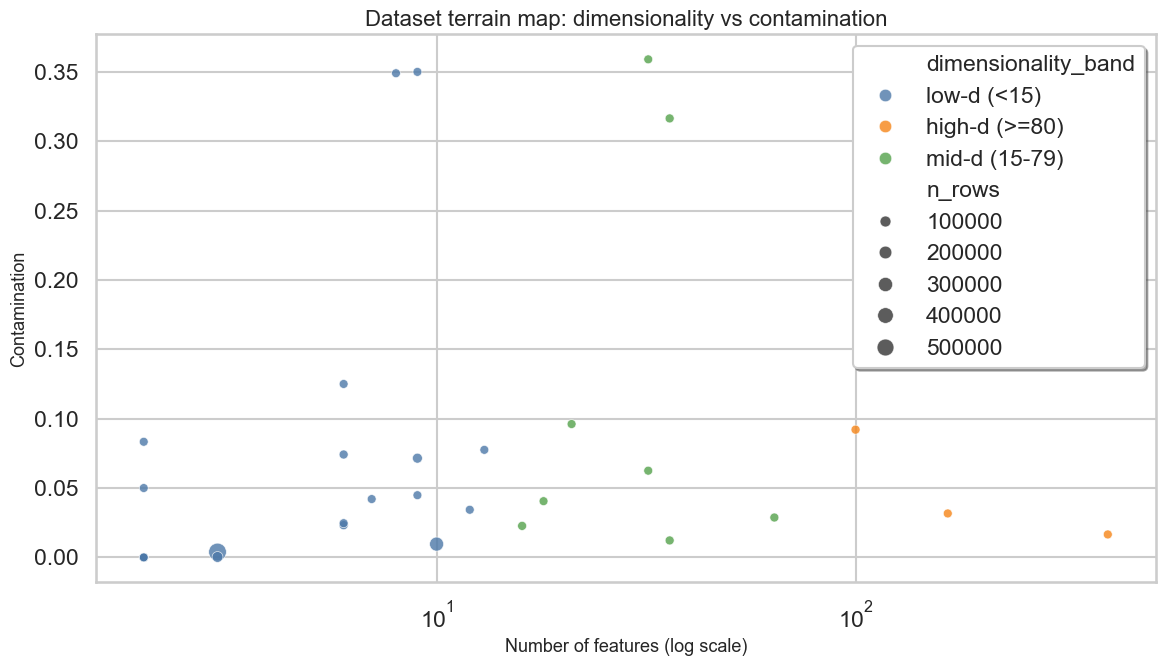

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=descriptive,
    x="n_features",
    y="contamination",
    size="n_rows",
    hue="dimensionality_band",
    alpha=0.8,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Dataset terrain map: dimensionality vs contamination")
ax.set_xlabel("Number of features (log scale)")
ax.set_ylabel("Contamination")
ax.legend(frameon=True, fancybox=True, shadow=True, loc="best")
plt.savefig(FIGURES_DIR / "phase6_dataset_terrain_map.png", bbox_inches="tight", dpi=300)
plt.tight_layout()

## Hypotheses (Q1-Q5)

- Q1: Prior-dependent methods should react more strongly to contamination shifts.
- Q2: IForest should stay flatter than LOF as dimensionality stress increases.
- Q3: The ECOD-LOF gap should grow on more correlated datasets.
- Q4: Algorithm redundancy can be tested with Kendall rank correlation.
- Q5: Elbow-based contamination should be compared against known ODDS rates.